In [3]:
import numpy as np
import matplotlib.pyplot as plt

def load_power(filename):
    """Load a power spectrum file with columns k, power, modes.
    Removes rows where k is nan or where k/power are zero."""
    k, power, modes = np.loadtxt(filename, unpack=True)
    mask = np.isfinite(k) & np.isfinite(power) & (k > 0) & (power > 0)
    return k[mask], power[mask], modes[mask]

scale_factors = [0.1681, 0.1792, 0.1908]
redshifts = [1 / a - 1 for a in scale_factors]

power_data = {}
for a in scale_factors:
    k_dm, power_dm, modes_dm = load_power(f"power-DM-{a}.txt")
    k_bar, power_bar, modes_bar = load_power(f"power-bar-{a}.txt")
    power_data[a] = {"dm": (k_dm, power_dm), "bar": (k_bar, power_bar)}

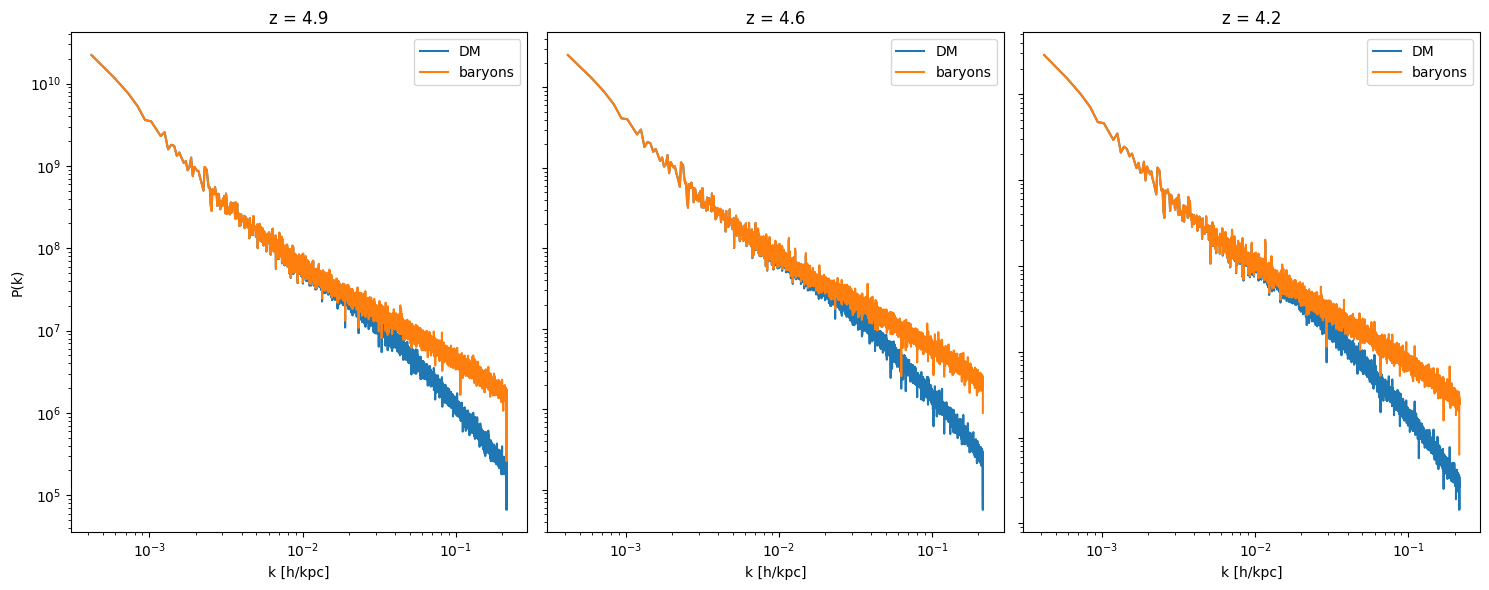

In [15]:
fig, axes = plt.subplots( 1, len(scale_factors), figsize=(5 * len(scale_factors), 6), sharex=True)

for ax, a, z in zip(axes, scale_factors, redshifts):
    k_dm, power_dm = power_data[a]["dm"]
    k_bar, power_bar = power_data[a]["bar"]
    ax.loglog(k_dm, power_dm, label="DM")
    ax.loglog(k_bar, power_bar, label="baryons")
    ax.set_xlabel("k [h/kpc]")
    ax.set_title(f"z = {z:.1f}")
    ax.legend()

axes[0].set_ylabel("P(k)")
for ax in axes[1:]:
    ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(wspace=0.00)
plt.tight_layout()

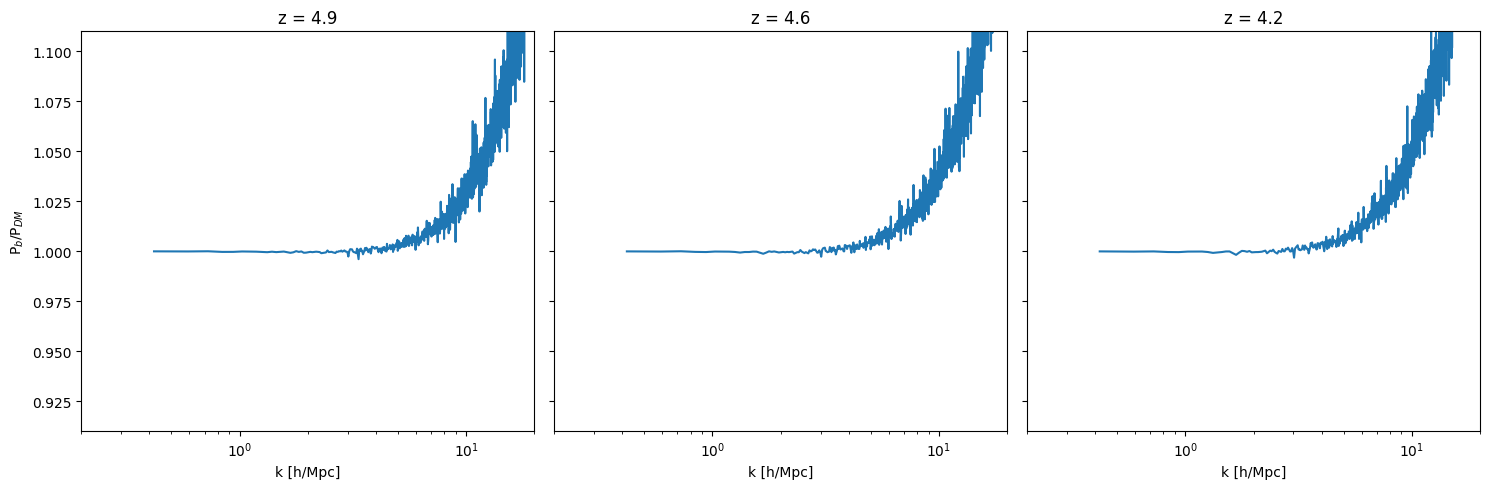

In [4]:
fig, axes = plt.subplots(1, len(scale_factors), figsize=(5* len(scale_factors), 5), sharex=True)

for ax, a, z in zip(axes, scale_factors, redshifts):
    k_dm, power_dm = power_data[a]["dm"]
    k_bar, power_bar = power_data[a]["bar"]
    ax.plot(k_dm * 1e3, power_bar / power_dm)
    ax.set_xscale('log')
    ax.set_xlabel("k [h/Mpc]")
    ax.set_title(f"z = {z:.1f}")
    ax.set_ylim(0.91, 1.11)
    ax.set_xlim(2e-1, 2e1)

axes[0].set_ylabel(r"P$_b$/P$_{DM}$")
for ax in axes[1:]:
    ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(wspace=0.00)
plt.tight_layout()